In [48]:
# Importing all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [49]:
# Load the dataset
df_raw = pd.read_csv('D:\jupyter notebook\stores_sales_forecasting.csv', encoding='latin-1')

print(f' Dataset loaded successfully!')
print(f'   Total rows    : {df_raw.shape[0]}')
print(f'   Total columns : {df_raw.shape[1]}')
print(f'\nAll columns:')
print(df_raw.columns.tolist())

 Dataset loaded successfully!
   Total rows    : 2121
   Total columns : 21

All columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [50]:
# Preview the raw data
df_raw.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [51]:
# Select only the columns we need for our model
df = df_raw[['Category', 'Sub-Category', 'Region', 'Ship Mode', 'Segment',
             'Quantity', 'Discount', 'Profit', 'Sales']].copy()

print(f'Working dataset shape: {df.shape}')
df.head(10)

Working dataset shape: (2121, 9)


,Category,Sub-Category,Region,Ship Mode,Segment,Quantity,Discount,Profit,Sales
0,Furniture,Bookcases,South,Second Class,Consumer,2,0.00,41.9136,261.9600
1,Furniture,Chairs,South,Second Class,Consumer,3,0.00,219.5820,731.9400
2,Furniture,Tables,South,Standard Class,Consumer,5,0.45,-383.0310,957.5775
3,Furniture,Furnishings,West,Standard Class,Consumer,7,0.00,14.1694,48.8600
4,Furniture,Tables,West,Standard Class,Consumer,9,0.20,85.3092,1706.1840
5,Furniture,Chairs,East,Second Class,Consumer,2,0.30,-1.0196,71.3720
6,Furniture,Tables,West,Standard Class,Consumer,3,0.00,240.2649,1044.6300
7,Furniture,Bookcases,East,Standard Class,Consumer,7,0.50,-1665.0522,3083.4300
8,Furniture,Furnishings,East,Standard Class,Consumer,3,0.20,15.5250,124.2000
9,Furniture,Furnishings,Central,First Class,Corporate,5,0.60,-147.9630,190.9200


In [52]:
# Basic info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Category      2121 non-null   str    
 1   Sub-Category  2121 non-null   str    
 2   Region        2121 non-null   str    
 3   Ship Mode     2121 non-null   str    
 4   Segment       2121 non-null   str    
 5   Quantity      2121 non-null   int64  
 6   Discount      2121 non-null   float64
 7   Profit        2121 non-null   float64
 8   Sales         2121 non-null   float64
dtypes: float64(3), int64(1), str(5)
memory usage: 149.3 KB


In [53]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,Quantity,Discount,Profit,Sales
count,2121.00,2121.00,2121.00,2121.00
mean,3.79,0.17,8.70,349.83
std,2.25,0.18,136.05,503.18
min,1.00,0.00,-1862.31,1.89
25%,2.00,0.00,-12.85,47.04
50%,3.00,0.20,7.77,182.22
75%,5.00,0.30,33.73,435.17
max,14.00,0.70,1013.13,4416.17


In [54]:
# Check for missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n No missing values!' if df.isnull().sum().sum() == 0 else '\n⚠️ Missing values detected!')

=== Missing Values ===
Category        0
Sub-Category    0
Region          0
Ship Mode       0
Segment         0
Quantity        0
Discount        0
Profit          0
Sales           0
dtype: int64

 No missing values!


In [55]:
# Unique values in categorical columns
print('=== Unique Values in Categorical Columns ===')
for col in ['Category', 'Sub-Category', 'Region', 'Ship Mode', 'Segment']:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

=== Unique Values in Categorical Columns ===
  Category: ['Furniture']
  Sub-Category: ['Bookcases', 'Chairs', 'Furnishings', 'Tables']
  Region: ['Central', 'East', 'South', 'West']
  Ship Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Segment: ['Consumer', 'Corporate', 'Home Office']


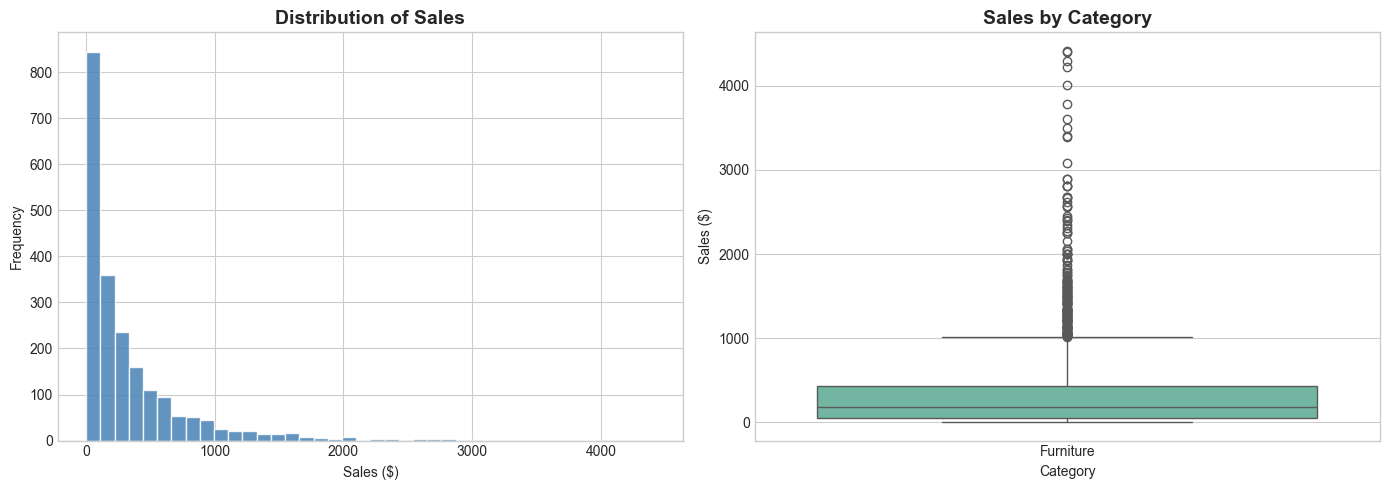


📌 Sales are right-skewed — most orders are small but a few are very large.


In [56]:
# --- Plot 1: Sales Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x='Category', y='Sales', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Sales by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()
print('\n📌 Sales are right-skewed — most orders are small but a few are very large.')

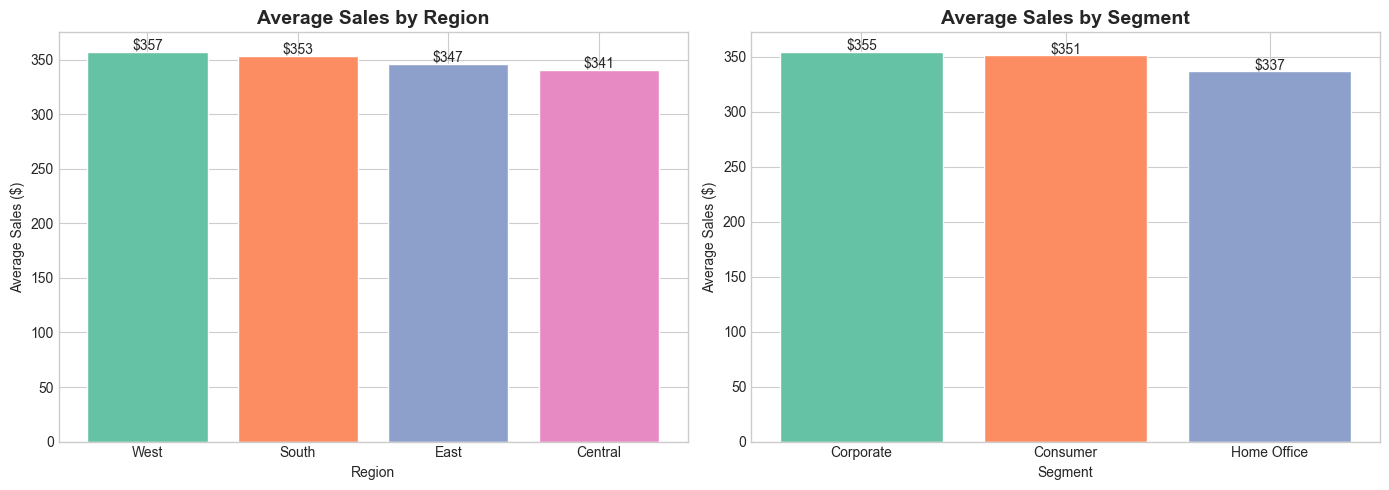

In [57]:
# --- Plot 2: Sales by Region and Segment ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_sales = df.groupby('Region')['Sales'].mean().sort_values(ascending=False)
axes[0].bar(region_sales.index, region_sales.values,
            color=sns.color_palette('Set2', len(region_sales)), edgecolor='white')
axes[0].set_title('Average Sales by Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Average Sales ($)')
for i, v in enumerate(region_sales.values):
    axes[0].text(i, v + 2, f'${v:.0f}', ha='center', fontsize=10)

segment_sales = df.groupby('Segment')['Sales'].mean().sort_values(ascending=False)
axes[1].bar(segment_sales.index, segment_sales.values,
            color=sns.color_palette('Set2', len(segment_sales)), edgecolor='white')
axes[1].set_title('Average Sales by Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Average Sales ($)')
for i, v in enumerate(segment_sales.values):
    axes[1].text(i, v + 2, f'${v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

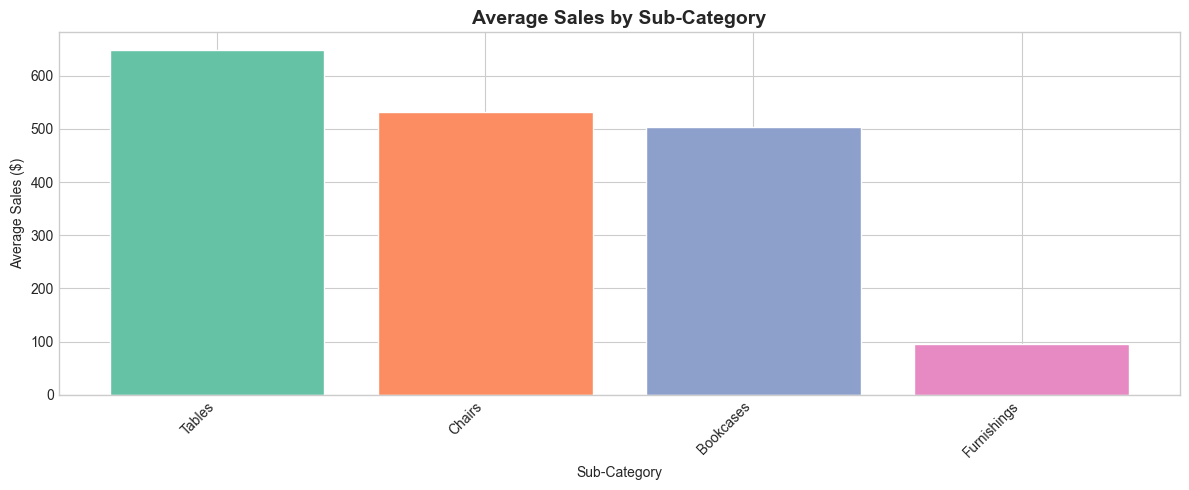

In [58]:
# --- Plot 3: Average Sales by Sub-Category ---
plt.figure(figsize=(12, 5))
subcat_sales = df.groupby('Sub-Category')['Sales'].mean().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(subcat_sales))
plt.bar(subcat_sales.index, subcat_sales.values, color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Average Sales by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Average Sales ($)')
plt.tight_layout()
plt.show()

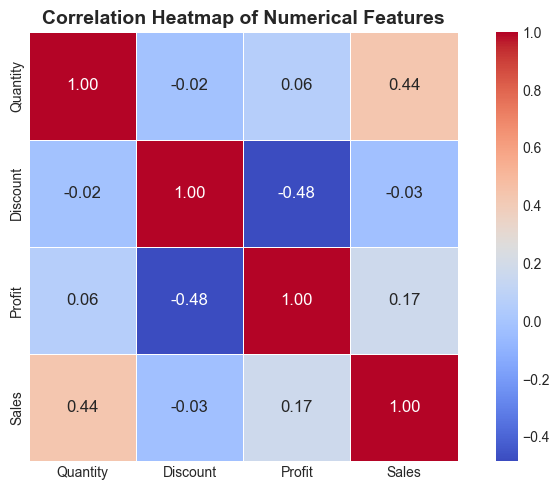


📌 Key Observations:
  Quantity & Sales : 0.44
  Discount & Sales : -0.03
  Profit & Sales   : 0.17


In [59]:
# --- Plot 4: Correlation Heatmap ---
plt.figure(figsize=(8, 5))
corr = df[['Quantity', 'Discount', 'Profit', 'Sales']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 12}, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Key Observations:')
print(f'  Quantity & Sales : {corr.loc["Quantity","Sales"]:.2f}')
print(f'  Discount & Sales : {corr.loc["Discount","Sales"]:.2f}')
print(f'  Profit & Sales   : {corr.loc["Profit","Sales"]:.2f}')

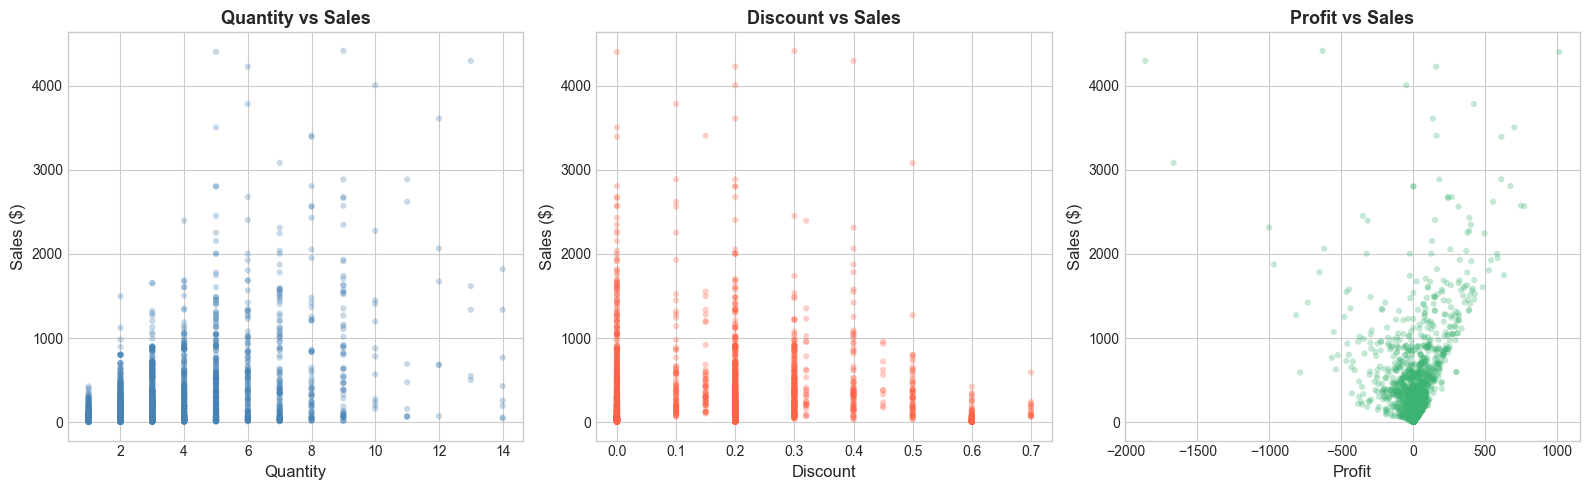

In [60]:
# --- Plot 5: Scatter plots of numerical features vs Sales ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['Quantity', 'Discount', 'Profit'],
                          ['steelblue', 'tomato', 'mediumseagreen']):
    ax.scatter(df[col], df['Sales'], alpha=0.3, color=color, edgecolors='none', s=20)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Sales ($)', fontsize=12)
    ax.set_title(f'{col} vs Sales', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [61]:
# Make a copy to preserve original data
df_model = df.copy()

# Label encode categorical columns and save mappings
label_encoders = {}
label_maps     = {}

categorical_cols = ['Category', 'Sub-Category', 'Region', 'Ship Mode', 'Segment']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    label_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  ✅ "{col}" encoded → {label_maps[col]}')

print('\n--- Encoded Dataset Sample ---')
df_model.head()

  ✅ "Category" encoded → {'Furniture': np.int64(0)}
  ✅ "Sub-Category" encoded → {'Bookcases': np.int64(0), 'Chairs': np.int64(1), 'Furnishings': np.int64(2), 'Tables': np.int64(3)}
  ✅ "Region" encoded → {'Central': np.int64(0), 'East': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
  ✅ "Ship Mode" encoded → {'First Class': np.int64(0), 'Same Day': np.int64(1), 'Second Class': np.int64(2), 'Standard Class': np.int64(3)}
  ✅ "Segment" encoded → {'Consumer': np.int64(0), 'Corporate': np.int64(1), 'Home Office': np.int64(2)}

--- Encoded Dataset Sample ---


,Category,Sub-Category,Region,Ship Mode,Segment,Quantity,Discount,Profit,Sales
0,0,0,2,2,0,2,0.00,41.9136,261.9600
1,0,1,2,2,0,3,0.00,219.5820,731.9400
2,0,3,2,3,0,5,0.45,-383.0310,957.5775
3,0,2,3,3,0,7,0.00,14.1694,48.8600
4,0,3,3,3,0,9,0.20,85.3092,1706.1840


In [62]:
# Define features (X) and target variable (y)
feature_cols = ['Category', 'Sub-Category', 'Region', 'Ship Mode', 'Segment',
                'Quantity', 'Discount', 'Profit']

X = df_model[feature_cols]
y = df_model['Sales']

print(f'Features (X) shape : {X.shape}')
print(f'Target   (y) shape : {y.shape}')
print(f'\nFeatures used: {feature_cols}')

Features (X) shape : (2121, 8)
Target   (y) shape : (2121,)

Features used: ['Category', 'Sub-Category', 'Region', 'Ship Mode', 'Segment', 'Quantity', 'Discount', 'Profit']


In [63]:
# Train-Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing  set : {X_test.shape[0]} samples')
print('\n✅ Data split complete! (80% Train / 20% Test)')

Training set : 1696 samples
Testing  set : 425 samples

✅ Data split complete! (80% Train / 20% Test)


In [64]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Model trained successfully!')
print(f'\nModel Intercept (b) : {model.intercept_:.4f}')
print('\nFeature Coefficients:')
for feat, coef in zip(feature_cols, model.coef_):
    print(f'  {feat:<18} → {coef:+.4f}')

✅ Model trained successfully!

Model Intercept (b) : 7.3712

Feature Coefficients:
  Category           → +0.0000
  Sub-Category       → -44.1732
  Region             → +4.6439
  Ship Mode          → +9.0697
  Segment            → -2.0252
  Quantity           → +95.6527
  Discount           → +118.8384
  Profit             → +0.5144


In [65]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('====================================')
print('      MODEL EVALUATION RESULTS      ')
print('====================================')
print(f'  Mean Absolute Error  (MAE)  : ${mae:.2f}')
print(f'  Root Mean Sq. Error  (RMSE) : ${rmse:.2f}')
print(f'  R² Score                    : {r2:.4f}')
print('====================================\n')

if r2 >= 0.7:
    print('✅ Good model performance! R² ≥ 0.70')
elif r2 >= 0.5:
    print('⚠️ Moderate performance. R² between 0.5–0.7')
else:
    print('❌ Low R². This is common for Linear Regression on Superstore data due to outliers.')
    print('   💡 Tip: Try log-transforming Sales or using Random Forest for better results.')

      MODEL EVALUATION RESULTS      
  Mean Absolute Error  (MAE)  : $289.28
  Root Mean Sq. Error  (RMSE) : $492.45
  R² Score                    : 0.2086

❌ Low R². This is common for Linear Regression on Superstore data due to outliers.
   💡 Tip: Try log-transforming Sales or using Random Forest for better results.


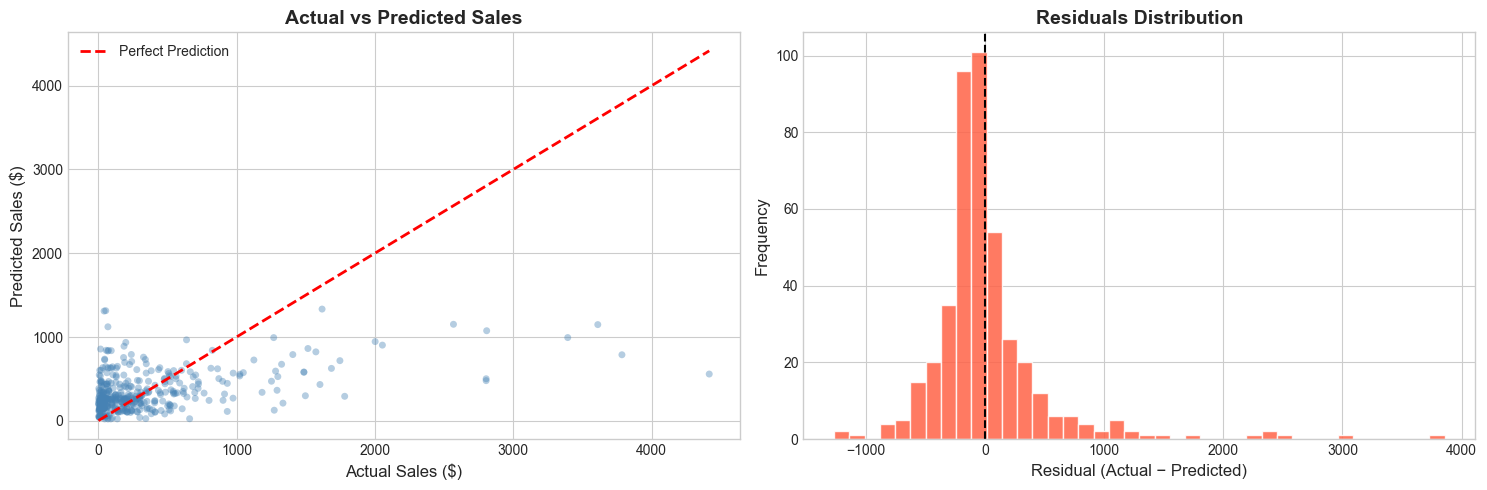

In [66]:
# --- Plot 6: Actual vs Predicted Sales ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none', s=25)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Sales ($)', fontsize=12)
axes[0].set_title('Actual vs Predicted Sales', fontsize=14, fontweight='bold')
axes[0].legend()

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residuals Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

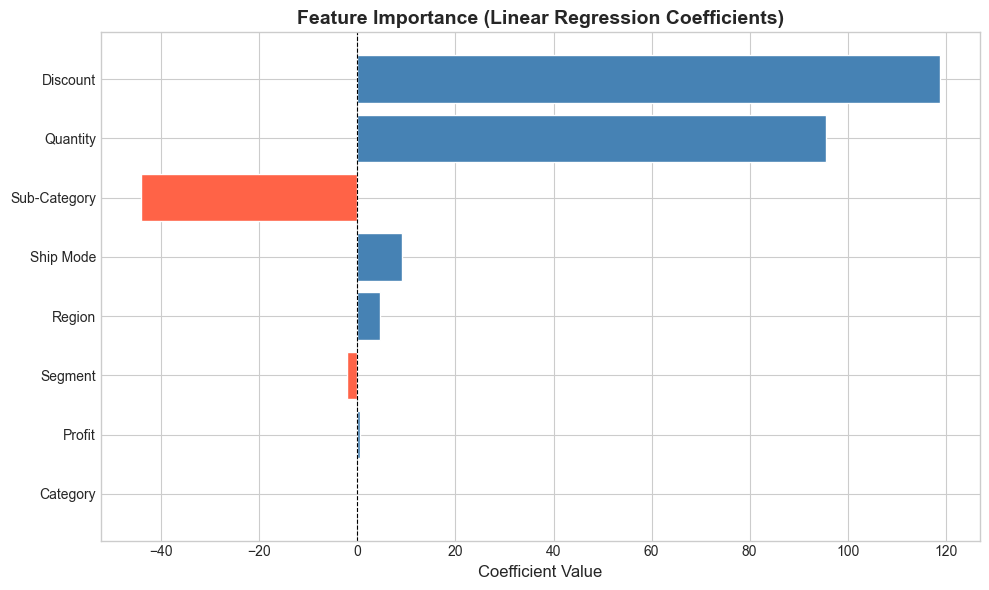

Blue = Positive impact on Sales
Red  = Negative impact on Sales


In [67]:
# --- Plot 7: Feature Importance (Coefficients) ---
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)

colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Importance (Linear Regression Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Blue = Positive impact on Sales')
print('Red  = Negative impact on Sales')

In [68]:
# Print encoding reference — so you know valid input values
print('📋 Valid input values for each category:')
for col, mapping in label_maps.items():
    print(f'  {col}: {list(mapping.keys())}')

📋 Valid input values for each category:
  Category: ['Furniture']
  Sub-Category: ['Bookcases', 'Chairs', 'Furnishings', 'Tables']
  Region: ['Central', 'East', 'South', 'West']
  Ship Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
  Segment: ['Consumer', 'Corporate', 'Home Office']


In [72]:
# --- Predict for a new order ---
# ✏️ Only use values from YOUR dataset below!

new_category    = 'Furniture'        # Only option: 'Furniture'
new_subcategory = 'Chairs'           # Bookcases / Chairs / Furnishings / Tables
new_region      = 'West'             # Central / East / South / West
new_shipmode    = 'First Class'      # First Class / Same Day / Second Class / Standard Class
new_segment     = 'Corporate'        # Consumer / Corporate / Home Office
new_quantity    = 5
new_discount    = 0.1
new_profit      = 120.0

# Encode using saved label maps
new_order = pd.DataFrame([{
    'Category'     : label_maps['Category'][new_category],
    'Sub-Category' : label_maps['Sub-Category'][new_subcategory],
    'Region'       : label_maps['Region'][new_region],
    'Ship Mode'    : label_maps['Ship Mode'][new_shipmode],
    'Segment'      : label_maps['Segment'][new_segment],
    'Quantity'     : new_quantity,
    'Discount'     : new_discount,
    'Profit'       : new_profit
}])

predicted_sales = model.predict(new_order)[0]
print(f'  🎯 Predicted Sales : ${predicted_sales:.2f}')

  🎯 Predicted Sales : $526.98
